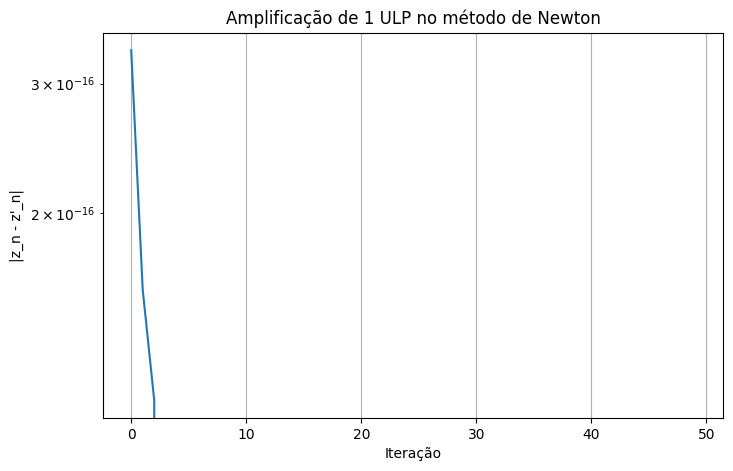

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def newton_step(z):
    f = z**3 - 1
    df = 3*z**2
    return z - f/df


def orbit(z0, n):
    z = z0
    arr = []
    for _ in range(n):
        z = newton_step(z)
        arr.append(z)
    return np.array(arr)


# ponto inicial perto da fronteira fractal
z0 = np.complex128(-0.1 + 0.7j)

# perturbação de 1 ULP
z0_ulp = np.nextafter(z0.real, np.inf) + 1j*np.nextafter(z0.imag, np.inf)

N = 50

o1 = orbit(z0, N)
o2 = orbit(z0_ulp, N)

diff = np.abs(o1 - o2)

plt.figure(figsize=(8,5))
plt.plot(diff)
plt.yscale("log")
plt.xlabel("Iteração")
plt.ylabel("|z_n - z'_n|")
plt.title("Amplificação de 1 ULP no método de Newton")
plt.grid(True)
plt.show()